In [2]:
'''
Relacionar google drive con Collab, para poder usar mi drive como almacenamiento de archivos,
y como lugar donde van a reposar los outputs que se generen en este script.
'''

import os
from google.colab import drive

# Unmount the drive if it's already mounted
try:
  drive.flush_and_unmount()
except ValueError:
  pass

# Ensure the mount point is clean by removing it if it exists
mountpoint = '/content/t6drive'
if os.path.exists(mountpoint):
    # Use rmdir for empty directories, or rmtree for non-empty ones
    # Since the error suggests it's not empty, let's try rmtree
    import shutil
    try:
        shutil.rmtree(mountpoint)
        print(f"Removed existing mount point directory: {mountpoint}")
    except OSError as e:
        print(f"Error removing directory {mountpoint}: {e}")


drive.mount(mountpoint, force_remount=True)
# Ejecutar el código anterior y aceptar lo solicitado; permisos y accesos

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/t6drive


In [3]:
'''
Importación de paquetes módulos y funciones. Cabe aclarar que no es necesario
importarlastodos al inicio, solo que es una práctica heredada de la codificación
tradicional que ayuda a ser mas eficiente la interpretación del código así como
su lectura.
'''
import os  # Operaciones con el sistema de archivos: rutas, crear carpetas, listar ficheros
import numpy as np  # Cálculo numérico y manejo de arreglos/matrices
import pandas as pd  # Manipulación de datos tabulares (DataFrames)
import matplotlib.pyplot as plt  # Visualización de datos y gráficos-
from scipy.io import loadmat  # Cargar archivos MATLAB .mat

# scikit-learn (ML)
from sklearn.preprocessing import StandardScaler  # Estandarización de variables (media 0, varianza 1)
from sklearn.cluster import KMeans  # Algoritmo de clustering K-Means
from sklearn.metrics import (  # Métricas para evaluación de modelos/clasificación
    confusion_matrix,           # Matriz de confusión (valores crudos)
    ConfusionMatrixDisplay,     # Visualización de la matriz de confusión
    accuracy_score,             # Exactitud
    f1_score,                   # F1-score (balance precisión/recobrado)
    precision_score,            # Precisión
    recall_score,               # Recall / Sensibilidad
    silhouette_score            # Coeficiente de silueta para evaluar clustering
)
from sklearn.metrics import pairwise_distances  # Distancias par a par entre observaciones
from scipy.cluster.hierarchy import (  # Clustering jerárquico y visualización
    linkage, dendrogram, fcluster
)
from scipy.spatial.distance import squareform
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold

In [5]:
'''
Definir las rutas para guardar las figuras, tablas y notebooks.
'''

# Definir las rutas base
base = '/content/t6drive/MyDrive/taller6'
figs = os.path.join(base, 'figuras')
codes = os.path.join(base, 'codes')
datos = os.path.join(base, 'datos')

# Crear las rutas sino existen
os.makedirs(figs, exist_ok=True)
os.makedirs(codes, exist_ok=True)
os.makedirs(datos, exist_ok=True)

PRIMER PUNTO TALLER 6

In [25]:
'''
Subir un archivo desde la máquina local a Colab.
'''
from google.colab import files

uploaded = files.upload()
fn = next(iter(uploaded.keys()))
print('Usuario subió el archivo "{name}" con tamaño {length} bytes'.format(
    name=fn, length=len(uploaded[fn])))

# Construir la ruta completa donde se guardará el archivo
ruta_archivo_subido = os.path.join(datos, fn)

# Guardar el archivo subido en el directorio 'datos'
with open(ruta_archivo_subido, 'wb') as f:
  f.write(uploaded[fn])

print(f"Archivo guardado en {ruta_archivo_subido}")

Saving Frogs_MFCCs.csv to Frogs_MFCCs (2).csv
Usuario subió el archivo "Frogs_MFCCs (2).csv" con tamaño 3181655 bytes
Archivo guardado en /content/t6drive/MyDrive/taller6/datos/Frogs_MFCCs (2).csv


In [28]:
'''
Cargar el archivo .mat, transformarlo a un DataFrame de pandas y guardarlo como .csv.
'''
ruta_archivo_subido = os.path.join(datos, 'data_clusters.mat')
try:
    mat_contents = loadmat(ruta_archivo_subido)
    print(f"Archivo .mat '{os.path.basename(ruta_archivo_subido)}' cargado exitosamente.")

    '''
    Identificar los datos relevantes en el archivo .mat.
    Los archivos .mat pueden tener varias variables; necesitamos encontrar la que contiene los datos.
    Podemos inspeccionar las claves del diccionario cargado.
    '''
    # Asumimos que los datos están en una clave específica o en la primera clave que no sea metadatos
    data_key = None
    for key in mat_contents:
        if not key.startswith('__'): # Ignorar claves de metadatos
            data_key = key
            break

    if data_key:
        data = mat_contents[data_key]
        print(f"Datos encontrados bajo la clave: '{data_key}'")

        '''
        Convertir los datos a un DataFrame de pandas.
        Asumimos que los datos tienen dos columnas.
        '''
        # Verificar las dimensiones de los datos
        if data.shape[1] >= 2:
            df = pd.DataFrame(data[:, :2], columns=['columnaA', 'columnaB'])
            print("Datos convertidos a DataFrame de pandas con encabezados.")

            '''
            Definir la ruta para el archivo .csv de salida.
            Se guardará en el mismo directorio 'datos' con el mismo nombre base pero extensión .csv.
            '''
            nombre_base = os.path.splitext(os.path.basename(ruta_archivo_subido))[0]
            ruta_csv_salida = os.path.join(datos, f"{nombre_base}.csv")

            '''
            Guardar el DataFrame en formato .csv.
            '''
            df.to_csv(ruta_csv_salida, index=False)
            print(f"Datos guardados exitosamente en formato .csv en: {ruta_csv_salida}")
        else:
            print(f"Error: Los datos en el archivo .mat no tienen al menos dos columnas. Dimensiones encontradas: {data.shape}")

    else:
        print("Error: No se encontraron datos relevantes en el archivo .mat (claves sin metadatos).")

except FileNotFoundError:
    print(f"Error: El archivo '{ruta_archivo_subido}' no fue encontrado. Asegúrate de haber subido el archivo correctamente.")
except Exception as e:
    print(f"Ocurrió un error al procesar el archivo .mat: {e}")

Error: El archivo '/content/t6drive/MyDrive/taller6/datos/data_clusters.mat' no fue encontrado. Asegúrate de haber subido el archivo correctamente.


In [29]:
'''
Visualizar los primeros registros del DataFrame y renombrar las columnas.
'''

# Renombrar las columnas del DataFrame
df.columns = ['A', 'B']

# Mostrar los primeros registros del DataFrame
display(df.head())

NameError: name 'df' is not defined

Aplicando agrupamiento jerárquico con método: single
Dendrograma guardado en: /content/t6drive/MyDrive/taller6/figuras/dendrograma_single.png


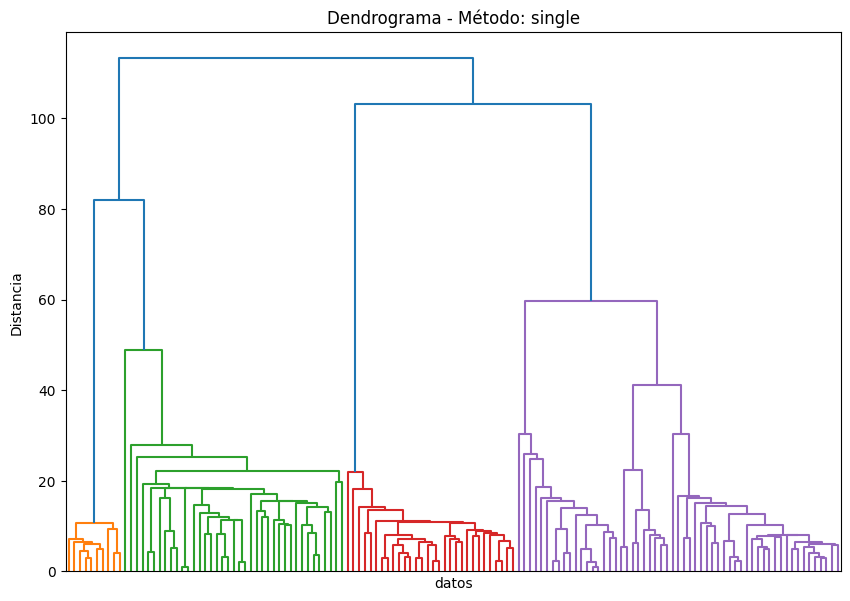

Aplicando agrupamiento jerárquico con método: complete
Dendrograma guardado en: /content/t6drive/MyDrive/taller6/figuras/dendrograma_complete.png


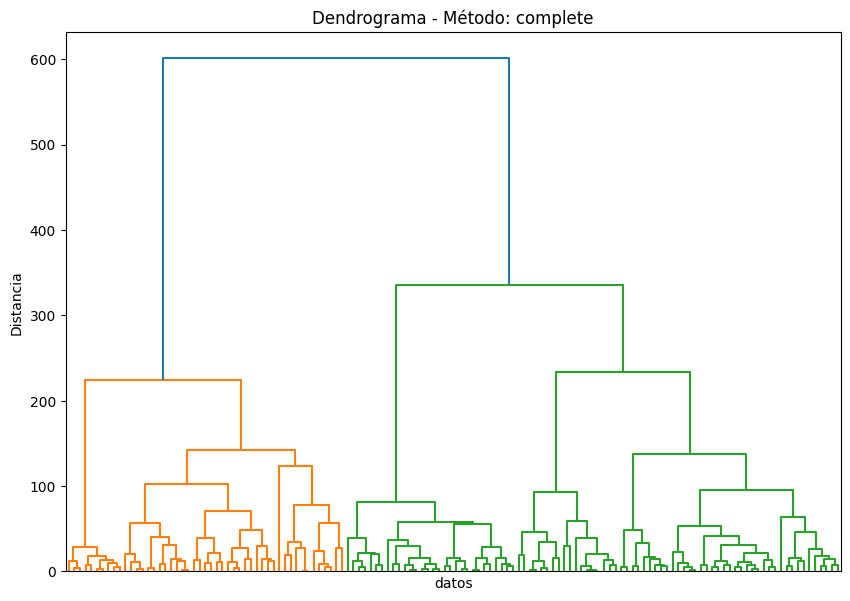

Aplicando agrupamiento jerárquico con método: centroid
Dendrograma guardado en: /content/t6drive/MyDrive/taller6/figuras/dendrograma_centroid.png


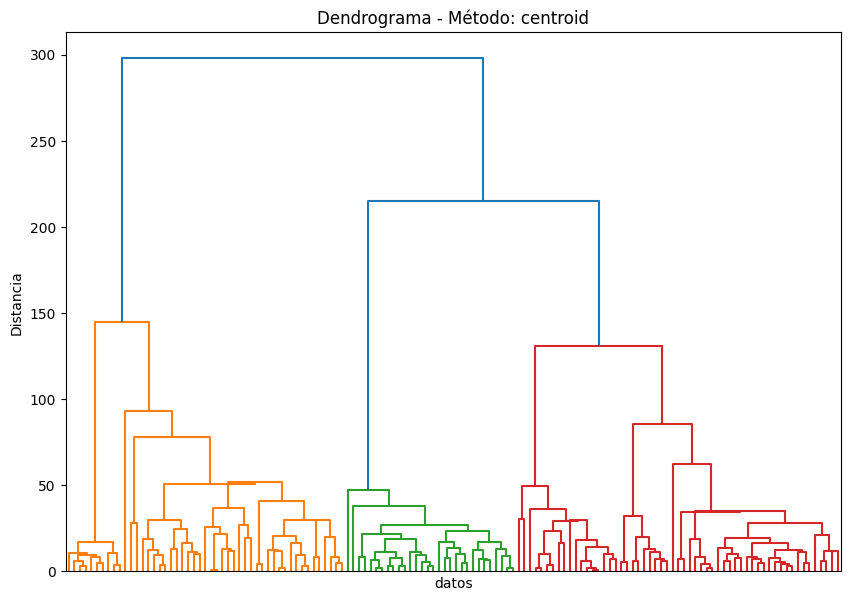

In [ ]:
'''
Generar agrupamiento jerárquico utilizando un dendograma para cada uno de los metodos definidos.
'''

# Definir los tres tipos de agrupamiento jerarquico que se va a realizar
metodos = ['single', 'complete', 'centroid']

# Asegurarse de que 'df' esté disponible y sea un DataFrame
if 'df' in locals() and isinstance(df, pd.DataFrame):
    # Iterar sobre los métodos de agrupamiento definidos
    for metodo in metodos:
        print(f"Aplicando agrupamiento jerárquico con método: {metodo}")

        # Calcular la matriz de linkage
        try:
            Z = linkage(df, method=metodo)

            # Generar el dendrograma
            plt.figure(figsize=(10, 7)) # Definir el tamaño de la figura
            plt.title(f'Dendrograma - Método: {metodo}') # Título del dendrograma
            plt.xlabel('datos') # Etiqueta del eje X
            plt.ylabel('Distancia') # Etiqueta del eje Y
            dendrogram(Z, no_labels=True) # Create the dendrogram without x-axis labels

            # Guardar la figura
            nombre_figura = f'dendrograma_{metodo}.png'
            ruta_figura = os.path.join(figs, nombre_figura)
            plt.savefig(ruta_figura)
            print(f"Dendrograma guardado en: {ruta_figura}")

            plt.show() # Mostrar el dendrograma

        except Exception as e:
            print(f"Error al aplicar el método '{metodo}': {e}")
else:
    print("Error: DataFrame 'df' no encontrado. Asegúrate de que se haya cargado y nombrado correctamente.")

== Evaluación jerárquica por método ==

Método: single
  K=2: Silhouette=0.5312 | SSE=108.94
  K=3: Silhouette=0.6260 | SSE=41.85
  K=4: Silhouette=0.6268 | SSE=30.19
  K=5: Silhouette=0.7121 | SSE=11.41
  K=6: Silhouette=0.6414 | SSE=10.97
  → Silhouette se estanca/baja en K=6. Detengo este método.
  ▶ K óptimo 'single': K=5 | Sil=0.7121 | SSE=11.41

Método: complete
  K=2: Silhouette=0.5312 | SSE=108.94
  K=3: Silhouette=0.5993 | SSE=45.75
  K=4: Silhouette=0.6880 | SSE=23.07
  K=5: Silhouette=0.7121 | SSE=11.41
  K=6: Silhouette=0.6315 | SSE=9.41
  → Silhouette se estanca/baja en K=6. Detengo este método.
  ▶ K óptimo 'complete': K=5 | Sil=0.7121 | SSE=11.41

Método: centroid
  K=2: Silhouette=0.5521 | SSE=118.00
  K=3: Silhouette=0.6260 | SSE=41.85
  K=4: Silhouette=0.6880 | SSE=23.07
  K=5: Silhouette=0.7121 | SSE=11.41
  K=6: Silhouette=0.6511 | SSE=10.34
  → Silhouette se estanca/baja en K=6. Detengo este método.
  ▶ K óptimo 'centroid': K=5 | Sil=0.7121 | SSE=11.41

== Mejor co

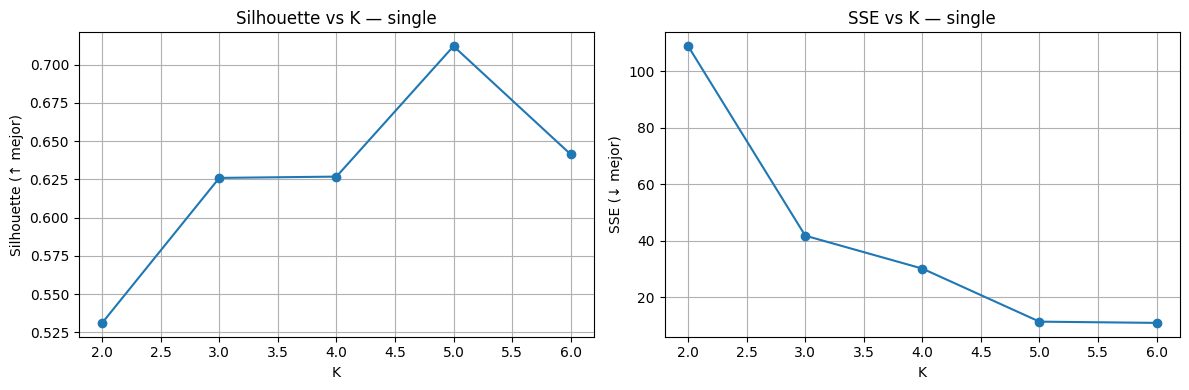

Figuras guardadas: /content/t6drive/MyDrive/taller6/figuras/jerarquico_complete_sil_sse.png


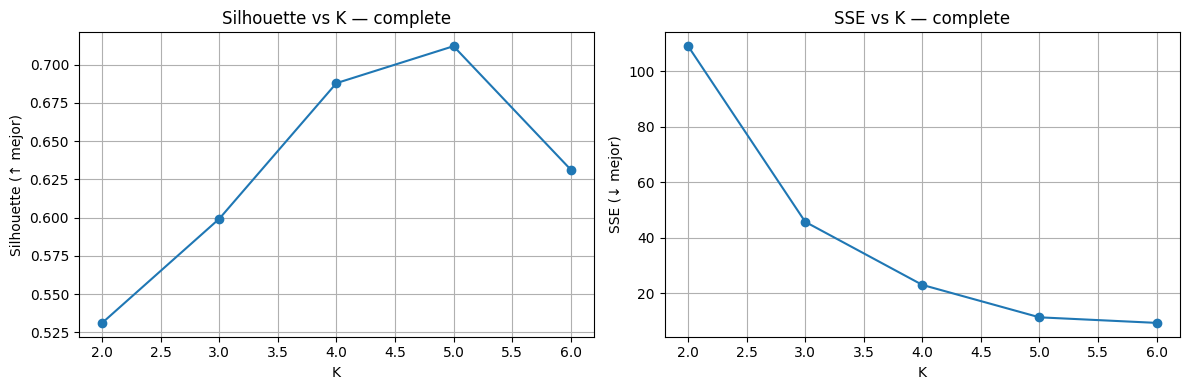

Figuras guardadas: /content/t6drive/MyDrive/taller6/figuras/jerarquico_centroid_sil_sse.png


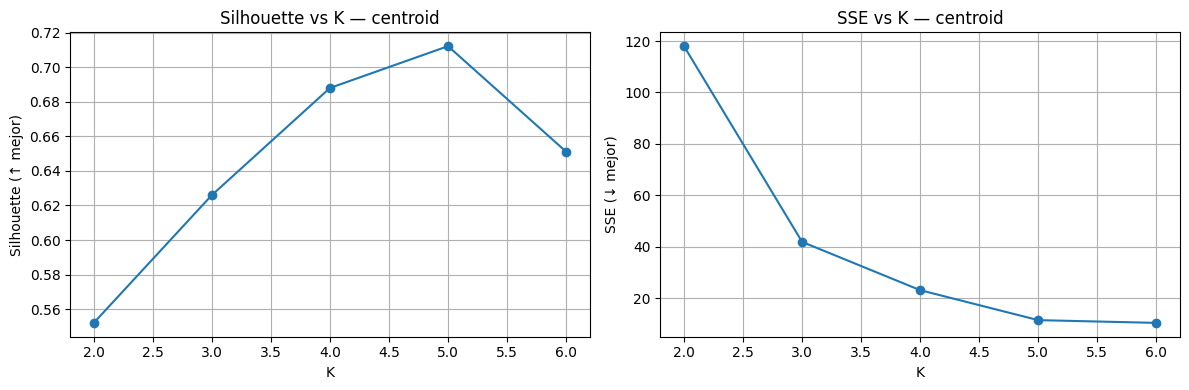

In [ ]:
'''
Evaluar K con Silhouette y SSE post-corte, elegir K óptimo y exportar etiquetas
'''

# Configuración
USE_SCALING   = True          # Estandarizar antes de calcular distancias/metrics
EARLY_STOP    = True          # Parar por meseta/descenso de Silhouette
K_MIN         = 2
n_samples     = df.shape[0]
K_MAX_DEFAULT = 10
K_MAX         = K_MAX_DEFAULT
K_RANGE       = range(K_MIN, K_MAX + 1)

# Matriz de trabajo
X_raw = df.to_numpy()
X = StandardScaler().fit_transform(X_raw) if USE_SCALING else X_raw

def sse_intra(X, labels):
    # SSE intra-cluster: suma de cuadrados al centroide de cada cluster
    sse = 0.0
    for c in np.unique(labels):
        xc = X[labels == c]
        center = xc.mean(axis=0)
        sse += ((xc - center) ** 2).sum()
    return float(sse)

# Estructuras de resultados
silhouette_scores = {m: {} for m in metodos}  # metodo -> {K: sil}
sse_scores        = {m: {} for m in metodos}  # metodo -> {K: sse}
best_by_method    = {}                        # metodo -> (K*, sil*, sse*)

print("== Evaluación jerárquica por método ==")
for metodo in metodos:
    print(f"\nMétodo: {metodo}")
    # Nota: 'centroid' usa euclidiana por defecto con linkage
    Z = linkage(X, method=metodo, metric='euclidean')

    prev_sil = -np.inf
    for k in K_RANGE:
        # Cortar el dendrograma a K clusters
        labels = fcluster(Z, k, criterion='maxclust')
        # Asegurar que haya al menos 2 clusters
        if len(np.unique(labels)) < 2:
            print(f" K={k}: <2 clusters distintos, se omite Silhouette.")
            continue

        sil = silhouette_score(X, labels, metric='euclidean')
        sse = sse_intra(X, labels)

        silhouette_scores[metodo][k] = sil
        sse_scores[metodo][k]        = sse

        print(f"  K={k}: Silhouette={sil:.4f} | SSE={sse:.2f}")

        # Parada temprana por meseta/descenso
        if EARLY_STOP and k > K_MIN and sil <= prev_sil:
            print(f" Silhouette se estanca/baja en K={k}. Detengo este método.")
            break
        prev_sil = sil

    # Elegir K óptimo por Silhouette para este método
    if silhouette_scores[metodo]:
        K_star = max(silhouette_scores[metodo], key=silhouette_scores[metodo].get)
        best_by_method[metodo] = (K_star,
                                  silhouette_scores[metodo][K_star],
                                  sse_scores[metodo][K_star])
        print(f" K óptimo '{metodo}': K={K_star} | Sil={silhouette_scores[metodo][K_star]:.4f} | SSE={sse_scores[metodo][K_star]:.2f}")
    else:
        print("(Sin valores de Silhouette calculados para este método)")

# Mejor combinación global (por Silhouette)
best_global = None  # (metodo, K, sil, sse)
for m, info in best_by_method.items():
    K_star, sil_star, sse_star = info
    if (best_global is None) or (sil_star > best_global[2]):
        best_global = (m, K_star, sil_star, sse_star)

if best_global is None:
    raise RuntimeError("No se pudo determinar un ganador global (revisa datos y rango de K).")

metodo_g, K_g, sil_g, sse_g = best_global
print("\n== Mejor combinación global por Silhouette ==")
print(f"Método: {metodo_g} | K: {K_g} | Silhouette: {sil_g:.4f} | SSE: {sse_g:.2f}")

# Gráficas por método: Silhouette y SSE vs K
for m in metodos:
    if not silhouette_scores[m]:
        continue
    Ks   = sorted(silhouette_scores[m].keys())
    sils = [silhouette_scores[m][k] for k in Ks]
    sses = [sse_scores[m][k]        for k in Ks]

    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    ax[0].plot(Ks, sils, marker='o')
    ax[0].set_title(f"Silhouette vs K — {m}")
    ax[0].set_xlabel("K"); ax[0].set_ylabel("Silhouette (↑ mejor)")
    ax[0].grid(True)

    ax[1].plot(Ks, sses, marker='o')
    ax[1].set_title(f"SSE vs K — {m}")
    ax[1].set_xlabel("K"); ax[1].set_ylabel("SSE (↓ mejor)")
    ax[1].grid(True)

    fig.tight_layout()
    figpath = os.path.join(figs, f"jerarquico_{m}_sil_sse.png")
    plt.savefig(figpath, dpi=120)
    print(f"Figuras guardadas: {figpath}")
    plt.show()

SEGUNDO PUNTO TALLER 6

In [6]:
'''
Subir el dataset (archivo .csv) desde la máquina local a Colab y guardarlo en la ruta de datos.
'''
from google.colab import files

uploaded_csv = files.upload()

# Asumimos que solo se sube un archivo CSV a la vez
if len(uploaded_csv) == 1:
    csv_filename = next(iter(uploaded_csv.keys()))
    print(f'Usuario subió el archivo "{csv_filename}" con tamaño {len(uploaded_csv[csv_filename])} bytes')

    # Construir la ruta completa donde se guardará el archivo CSV
    ruta_csv_subido = os.path.join(datos, csv_filename)

    # Guardar el archivo subido en el directorio 'datos'
    with open(ruta_csv_subido, 'wb') as f:
        f.write(uploaded_csv[csv_filename])

    print(f"Archivo CSV guardado en {ruta_csv_subido}")

else:
    print("Por favor, sube solo un archivo CSV.")

Saving Frogs_MFCCs.csv to Frogs_MFCCs.csv
Usuario subió el archivo "Frogs_MFCCs.csv" con tamaño 3181655 bytes


FileNotFoundError: [Errno 2] No such file or directory: '/content/t6drive/MyDrive/taller6/datos/Frogs_MFCCs.csv'

In [34]:
'''
Cargar el archivo CSV en un DataFrame y extraer las variables numéricas
excepto la última columna.
'''

# Cargar el archivo CSV
ruta_csv_cargado = os.path.join(datos, 'Frogs_MFCCs.csv')

try:
    df_loaded = pd.read_csv(ruta_csv_cargado)
    print(f"Archivo CSV '{os.path.basename(ruta_csv_cargado)}' cargado exitosamente.")

    # Seleccionar solo las columnas numéricas
    df_numeric = df_loaded.select_dtypes(include=np.number)

    # Eliminar la última columna numérica si existe más de una columna numérica
    if df_numeric.shape[1] > 1:
        df_numeric = df_numeric.iloc[:, :-1]
        print("Variables numéricas (excepto la última columna) extraídas.")
    elif df_numeric.shape[1] == 1:
        print("Solo se encontró una columna numérica, no se eliminó ninguna.")
    else:
        print("No se encontraron columnas numéricas en el DataFrame.")


    # Mostrar las primeras filas del nuevo DataFrame con variables numéricas
    display(df_numeric.head())

except FileNotFoundError:
    print(f"Error: El archivo '{ruta_csv_cargado}' no fue encontrado. Asegúrate de que el nombre del archivo y la ruta sean correctos.")
except Exception as e:
    print(f"Ocurrió un error al procesar el archivo CSV: {e}")

Archivo CSV 'Frogs_MFCCs.csv' cargado exitosamente.
Variables numéricas (excepto la última columna) extraídas.


,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_13,MFCCs_14,MFCCs_15,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.156436,0.082245,0.135752,-0.024017,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.254341,0.022786,0.163320,0.012022,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.237384,0.050791,0.207338,0.083536,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.317084,-0.011567,0.100413,-0.050224,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.298524,0.037439,0.219153,0.062837,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244


Calculando matriz de distancias (puede tardar un poco)…
== Evaluando PAM para g en [80, 100, 120, 150] ==
  g= 80 | Silhouette=0.1535 | Inercia(sum_dist)=1728.17
  g=100 | Silhouette=0.1465 | Inercia(sum_dist)=1668.93
  g=120 | Silhouette=0.1026 | Inercia(sum_dist)=1640.55
  g=150 | Silhouette=0.1061 | Inercia(sum_dist)=1583.35

== g* seleccionado: 80 ==

Protoclusters (primeras filas):


,proto_id,medoid_row_index,weight
0,0,3668,153
1,1,5858,17
2,2,105,122
3,3,6688,90
4,4,5929,455



Evaluación PAM (Silhouette e Inercia vs g):


,g,Silhouette,Inertia_sum_dist
0,80,0.153470,1728.169678
1,100,0.146493,1668.928955
2,120,0.102553,1640.545166
3,150,0.106081,1583.354736


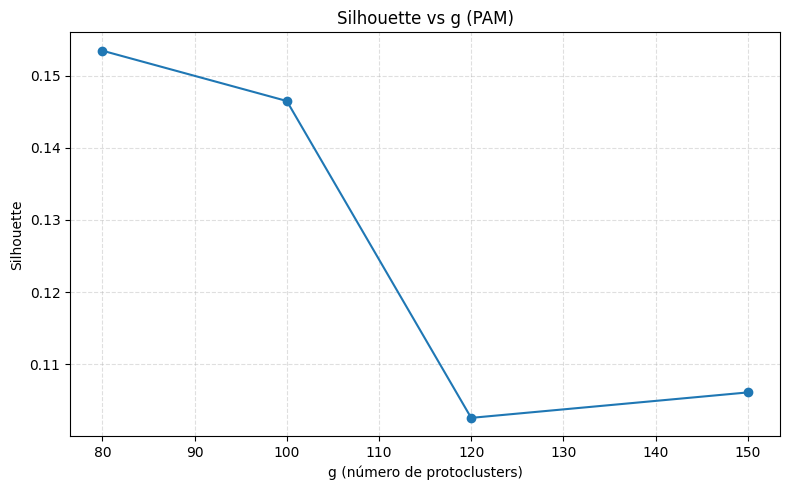

Figura guardada: /content/t6drive/MyDrive/taller6/figuras/silhouette_vs_g_kmedoids.png


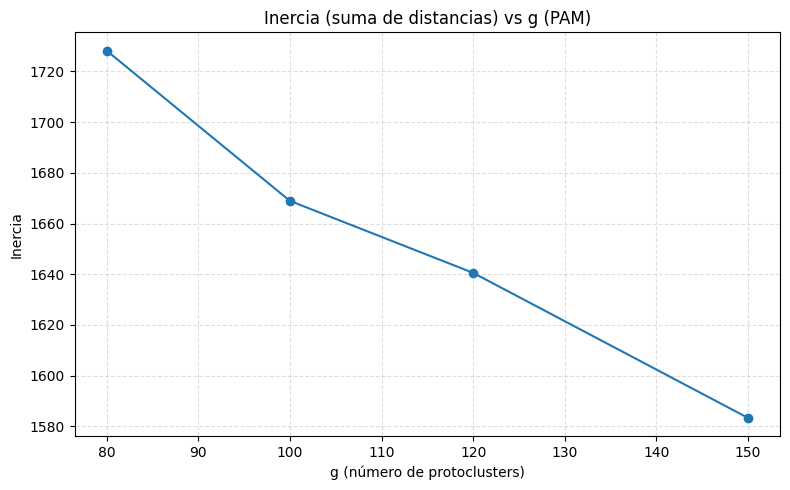

Figura guardada: /content/t6drive/MyDrive/taller6/figuras/inercia_vs_g_kmedoids.png


In [35]:
'''
Construir protoclusters con PAM (K-Medoids). Se seleccionan a partir de su
mejor rendimiento respecto a al inercia y al coeficiente de Silhouette. Se prueba
con varios tamaños de protoclusters (g). Se recalcula Silhouette e inercia para
el mejor g encontrado, se guardan metricas, grupos formados y los respectivos
k-medoides.
'''

# 1) Matriz de distancias (euclidiana) sobre todo el dataset
X = df_numeric.to_numpy(copy=False)
print("Calculando matriz de distancias (puede tardar un poco)…")
D = pairwise_distances(X, metric="euclidean").astype(np.float32)

# 2) PAM (K-medoids) en NumPy
def kmedoids_plus_plus_init(D, k, rng):
    n = D.shape[0]
    medoids = [int(rng.integers(0, n))]
    for _ in range(1, k):
        dmin = np.min(D[:, medoids], axis=1)
        probs = dmin**2
        s = probs.sum()
        if s == 0:
            cand = int(rng.choice(np.setdiff1d(np.arange(n), medoids)))
        else:
            probs = probs / s
            cand = int(rng.choice(np.arange(n), p=probs))
        medoids.append(cand)
    return np.array(medoids, dtype=int)

def pam_alternate(D, k, max_iter=20, rng=None):
    n = D.shape[0]
    medoids = kmedoids_plus_plus_init(D, k, rng)
    labels = np.argmin(D[:, medoids], axis=1)
    for _ in range(max_iter):
        changed = False
        new_medoids = medoids.copy()
        for j, m in enumerate(medoids):
            members = np.where(labels == j)[0]
            if len(members) == 0:
                candidate = int(np.argmax(np.min(D[:, medoids], axis=1)))
                new_medoids[j] = candidate; changed = True; continue
            if len(members) == 1:
                new_medoids[j] = members[0]; changed |= (new_medoids[j] != m); continue
            subD = D[np.ix_(members, members)]
            best_medoid = members[int(np.argmin(subD.sum(axis=1)))]
            if best_medoid != m:
                new_medoids[j] = best_medoid; changed = True
        medoids = np.array(new_medoids, dtype=int)
        new_labels = np.argmin(D[:, medoids], axis=1)
        if not changed and np.array_equal(new_labels, labels):
            break
        labels = new_labels
    inertia = D[np.arange(n), medoids[labels]].sum()
    return labels, medoids, float(inertia)

# 3) Barrido de g y selección de g*
g_values = [80, 100, 120, 150]
rng = np.random.default_rng(42)
max_iter_pam = 20

sil_by_g, inertia_by_g = {}, {}
print("== Evaluando PAM para g en", g_values, "==")
for g in g_values:
    labels_g, medoids_g, inertia_g = pam_alternate(D, g, max_iter=max_iter_pam, rng=rng)
    sil_g = silhouette_score(D, labels_g, metric="precomputed")
    sil_by_g[g] = sil_g; inertia_by_g[g] = inertia_g
    print(f"  g={g:>3} | Silhouette={sil_g:.4f} | Inercia(sum_dist)={inertia_g:.2f}")

best_sil = max(sil_by_g.values())
candidatos = [g for g, s in sil_by_g.items() if s == best_sil]
g_star = min(candidatos, key=lambda g: inertia_by_g[g])
print(f"\n== g* seleccionado: {g_star} ==")

# 4) Modelo final con g*
labels_protos, medoid_indices, inertia_final = pam_alternate(D, g_star, max_iter=max_iter_pam, rng=rng)
weights = np.bincount(labels_protos, minlength=g_star)
medoid_matrix_df = df_numeric.iloc[medoid_indices].reset_index(drop=True)

# 5) Resúmenes en memoria
proto_summary_df = pd.DataFrame({
    "proto_id": np.arange(g_star),
    "medoid_row_index": medoid_indices,
    "weight": weights
})
evaluation_summary_df = pd.DataFrame({
    "g": sorted(sil_by_g.keys()),
    "Silhouette": [sil_by_g[g] for g in sorted(sil_by_g.keys())],
    "Inertia_sum_dist": [inertia_by_g[g] for g in sorted(inertia_by_g.keys())]
})

print("\nProtoclusters (primeras filas):")
display(proto_summary_df.head())
print("\nEvaluación PAM (Silhouette e Inercia vs g):")
display(evaluation_summary_df)

# 6) Figuras: mostrar y guardar en figs/
plt.figure(figsize=(8,5))
plt.plot(evaluation_summary_df["g"], evaluation_summary_df["Silhouette"], marker="o")
plt.title("Silhouette vs g (PAM)")
plt.xlabel("g (número de protoclusters)"); plt.ylabel("Silhouette")
plt.grid(True, linestyle="--", alpha=0.4)
out1 = os.path.join(figs, "silhouette_vs_g_kmedoids.png")
plt.tight_layout(); plt.savefig(out1, dpi=150); plt.show()
print(f"Figura guardada: {out1}")

plt.figure(figsize=(8,5))
plt.plot(evaluation_summary_df["g"], evaluation_summary_df["Inertia_sum_dist"], marker="o")
plt.title("Inercia (suma de distancias) vs g (PAM)")
plt.xlabel("g (número de protoclusters)"); plt.ylabel("Inercia")
plt.grid(True, linestyle="--", alpha=0.4)
out2 = os.path.join(figs, "inercia_vs_g_kmedoids.png")
plt.tight_layout(); plt.savefig(out2, dpi=150); plt.show()
print(f"Figura guardada: {out2}")


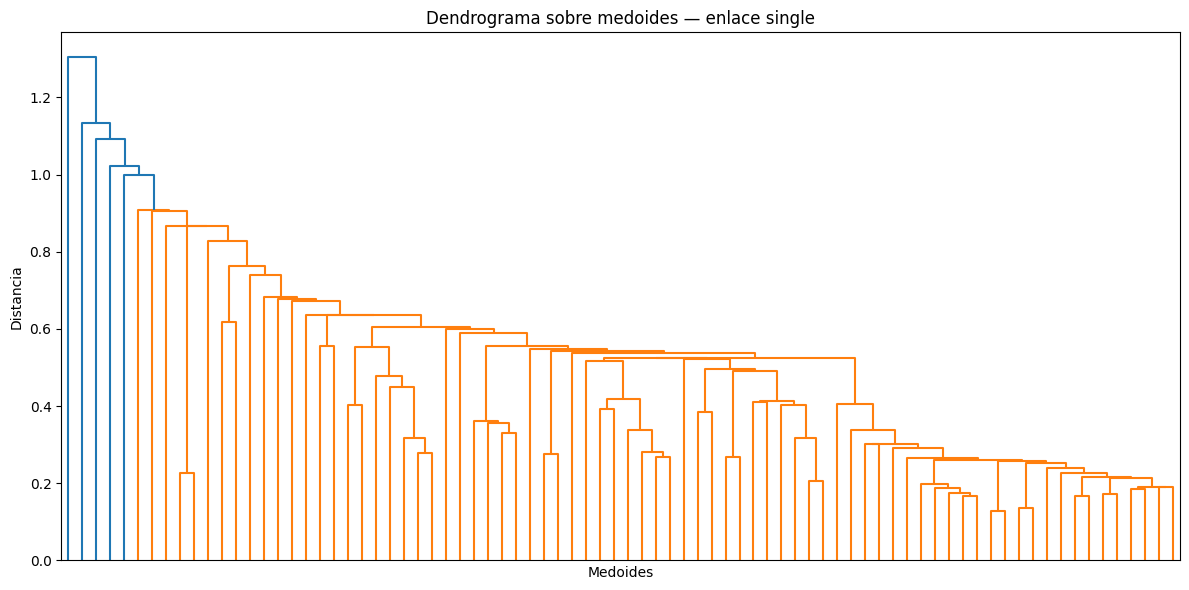

Figura guardada: /content/t6drive/MyDrive/taller6/figuras/dendrograma_medoides_single.png


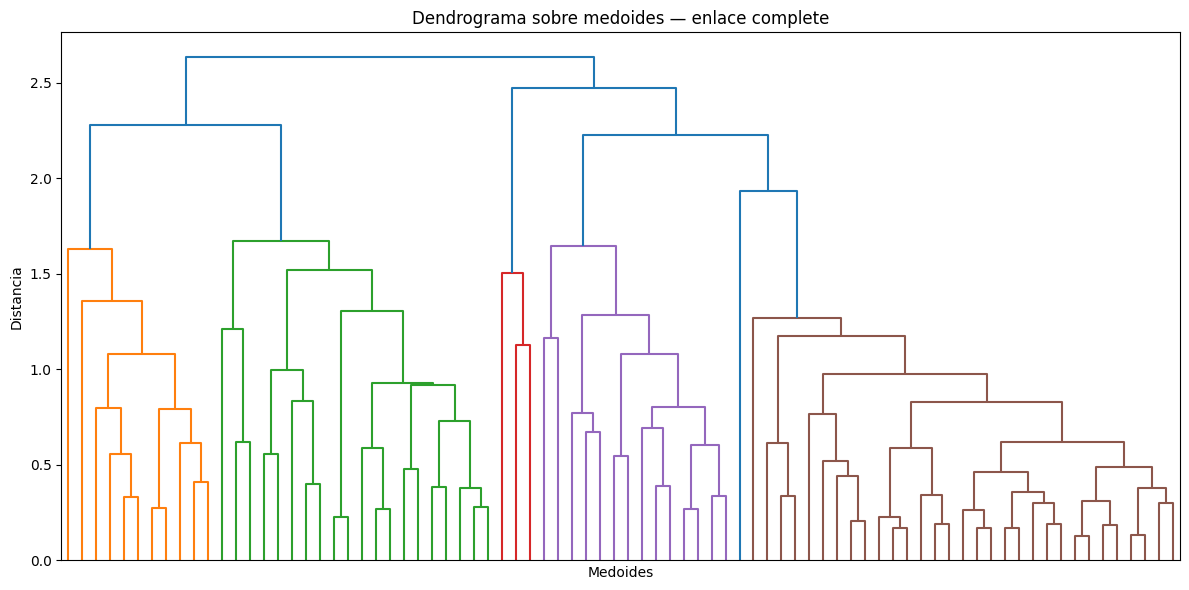

Figura guardada: /content/t6drive/MyDrive/taller6/figuras/dendrograma_medoides_complete.png


In [36]:
'''
Construccion de los dendogramas para los métodos single y complete, a partir
de los medoides identificados previamente.
'''

M = medoid_matrix_df.to_numpy(copy=False)
Dm = pairwise_distances(M, metric="euclidean")
Dm_condensed = squareform(Dm, checks=False)

methods = ["single", "complete"]
linkages = {}
for meth in methods:
    Z = linkage(Dm_condensed, method=meth)
    linkages[meth] = Z

    plt.figure(figsize=(12,6))
    dendrogram(Z, no_labels=True, count_sort=True)
    plt.title(f"Dendrograma sobre medoides — enlace {meth}")
    plt.xlabel("Medoides"); plt.ylabel("Distancia")
    out = os.path.join(figs, f"dendrograma_medoides_{meth}.png")
    plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
    print(f"Figura guardada: {out}")

,method,K,Silhouette_full
0,complete,2,0.293270
1,complete,3,0.281099
2,complete,4,0.299289
3,complete,5,0.360990
4,complete,6,0.361026
5,complete,7,0.358007
6,complete,8,0.354012
7,complete,9,0.353049
8,complete,10,0.332229
9,complete,11,0.325518


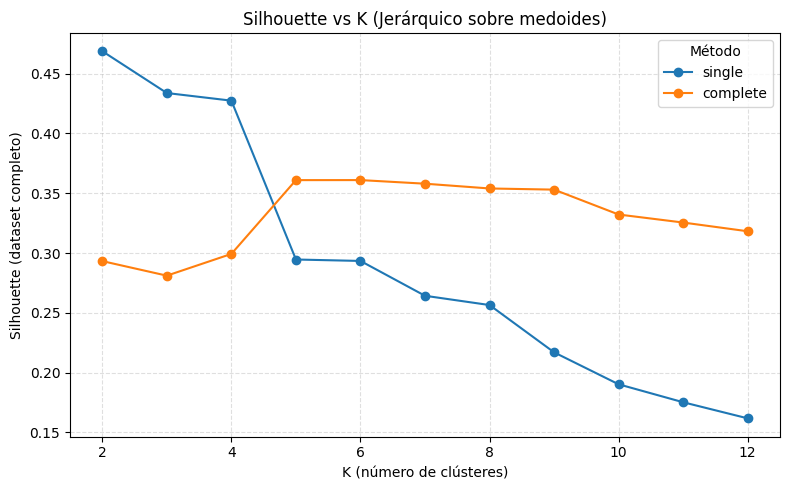

Figura guardada: /content/t6drive/MyDrive/taller6/figuras/silhouette_vs_K_hier_single_complete.png
Mejor configuración: método=single, K=2, Silhouette=0.4688


In [37]:
'''
A partir de los dendogramas construidos sobre los k-medoides generados,
se procede a cortar cada arbol en diferentes grupos o valores de k (variando
entre 2 y 12), para cada k se captura el valor de Silhouette, que permita comparar
cual arroja mejor rendimiento para ambso tipos de enlace.
'''

K_range = range(2, 13)
rows_eval = []

for meth, Z in linkages.items():
    for K in K_range:
        labels_medoides = fcluster(Z, t=K, criterion="maxclust") - 1
        labels_final = labels_medoides[labels_protos]  # propaga del protocluster a cada fila
        sil = silhouette_score(D, labels_final, metric="precomputed")
        rows_eval.append({"method": meth, "K": int(K), "Silhouette_full": float(sil)})

evaluation_hier_df = pd.DataFrame(rows_eval).sort_values(["method","K"]).reset_index(drop=True)
display(evaluation_hier_df)

# Gráfica Silhouette vs K por método (mostrar y guardar)
plt.figure(figsize=(8,5))
for meth in ["single", "complete"]:
    sub = evaluation_hier_df[evaluation_hier_df["method"] == meth]
    if not sub.empty:
        plt.plot(sub["K"], sub["Silhouette_full"], marker="o", label=meth)
plt.title("Silhouette vs K (Jerárquico sobre medoides)")
plt.xlabel("K (número de clústeres)"); plt.ylabel("Silhouette (dataset completo)")
plt.grid(True, linestyle="--", alpha=0.4); plt.legend(title="Método")
out = os.path.join(figs, "silhouette_vs_K_hier_single_complete.png")
plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
print(f"Figura guardada: {out}")

# Mostrar la mejor configuración en consola
best_idx = evaluation_hier_df["Silhouette_full"].idxmax()
best_method = evaluation_hier_df.loc[best_idx, "method"]
best_K = int(evaluation_hier_df.loc[best_idx, "K"])
best_sil = float(evaluation_hier_df.loc[best_idx, "Silhouette_full"])
print(f"Mejor configuración: método={best_method}, K={best_K}, Silhouette={best_sil:.4f}")


In [39]:

'''
Construir los datastes de entrenamiento, validación en entrenamiento y testeo,
respectivamente con tamaños 85% (no etiquetado), 5% (etiquetado) para entrenar
y 10% (etiquetado) para prueba. Se genera una nueva clasificación a partir de las
combinaciones de las variables family y genus del dataset original.
'''

# 1) Etiqueta Family|Genus
y_all = (df_loaded['Family'].astype(str) + '|' + df_loaded['Genus'].astype(str)).to_numpy()

# 2) Filtrado por umbral (>=20) para asegurar presencia en 5% y 10%
vc = pd.Series(y_all).value_counts()
valid_classes = set(vc[vc >= 20].index)
mask_valid = pd.Series(y_all).isin(valid_classes).to_numpy()

X_all = df_numeric.to_numpy(copy=False)[mask_valid]
y_all = y_all[mask_valid]

print(f"Dataset tras filtrar clases con >=20 instancias: {X_all.shape[0]} filas, {X_all.shape[1]} columnas, {len(valid_classes)} clases.")

# 3) Split estratificado: primero 10% validación externa (etiquetado)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx_90, val10_idx = next(sss1.split(X_all, y_all))
X_90, y_90 = X_all[train_idx_90], y_all[train_idx_90]
X_val10, y_val10 = X_all[val10_idx], y_all[val10_idx]

# 4) Del 90% restante: separar 5% etiquetado y 85% no etiquetado
#    (5% del total ≈ 5/90 del bloque 90%)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=(5/90), random_state=42)
unlabeled_idx_85, labeled_idx_5 = next(sss2.split(X_90, y_90))
X_train_unl, y_train_unl = X_90[unlabeled_idx_85], y_90[unlabeled_idx_85]
X_train_lab, y_train_lab = X_90[labeled_idx_5], y_90[labeled_idx_5]

print(f"Particiones:")
print(f"  5% etiquetado  : {X_train_lab.shape[0]} filas, clases={len(np.unique(y_train_lab))}")
print(f"  85% no etiqu.  : {X_train_unl.shape[0]} filas")
print(f"  10% validación : {X_val10.shape[0]} filas, clases={len(np.unique(y_val10))}")


Dataset tras filtrar clases con >=20 instancias: 7195 filas, 22 columnas, 8 clases.
Particiones:
  5% etiquetado  : 360 filas, clases=8
  85% no etiqu.  : 6115 filas
  10% validación : 720 filas, clases=8


In [41]:
'''
Definición de funciones auxiliares
'''
# Funciones auxiliares:
# - Matriz de distancias euclidianas
# - PAM (K-medoids) con init tipo k-medoids++
# - Jerárquico (linkage sobre medoides)
# - Elección de K por Silhouette en el pool (labeled+unlabeled)
# - Mapeo de clúster a clase por mayoría (usando SOLO el 5% etiquetado)
# - Métricas (macro-F1, accuracy, recall) y matriz de confusión

def euclidean_distances(X):
    return pairwise_distances(X, metric="euclidean").astype(np.float32)

def _kmedoids_plus_plus_init(D, k, rng):
    n = D.shape[0]
    medoids = [int(rng.integers(0, n))]
    for _ in range(1, k):
        dmin = np.min(D[:, medoids], axis=1)
        probs = dmin**2
        s = probs.sum()
        if s == 0:
            cand = int(rng.choice(np.setdiff1d(np.arange(n), medoids)))
        else:
            probs = probs / s
            cand = int(rng.choice(np.arange(n), p=probs))
        medoids.append(cand)
    return np.array(medoids, dtype=int)

def pam_kmedoids(D, k, max_iter=20, rng=None):
    n = D.shape[0]
    medoids = _kmedoids_plus_plus_init(D, k, rng)
    labels = np.argmin(D[:, medoids], axis=1)
    for _ in range(max_iter):
        changed = False
        new_medoids = medoids.copy()
        for j, m in enumerate(medoids):
            members = np.where(labels == j)[0]
            if len(members) == 0:
                candidate = int(np.argmax(np.min(D[:, medoids], axis=1)))
                new_medoids[j] = candidate; changed = True; continue
            if len(members) == 1:
                new_medoids[j] = members[0]; changed |= (new_medoids[j] != m); continue
            subD = D[np.ix_(members, members)]
            best_medoid = members[int(np.argmin(subD.sum(axis=1)))]
            if best_medoid != m:
                new_medoids[j] = best_medoid; changed = True
        medoids = np.array(new_medoids, dtype=int)
        new_labels = np.argmin(D[:, medoids], axis=1)
        if not changed and np.array_equal(new_labels, labels):
            break
        labels = new_labels
    inertia = D[np.arange(n), medoids[labels]].sum()
    return labels, medoids, float(inertia)

def build_linkage_on_medoids(M, method="single"):
    Dm = euclidean_distances(M)
    Z = linkage(squareform(Dm, checks=False), method=method)
    return Z, Dm

def choose_K_by_silhouette(D_pool, labels_protos, Z, K_range=range(2,13)):
    # Para cada K: etiquetas de medoides → propaga a todo el pool → Silhouette global (precomputed)
    best_sil, best_K = -1.0, None
    for K in K_range:
        labels_medoids = fcluster(Z, t=K, criterion="maxclust") - 1
        labels_full = labels_medoids[labels_protos]
        sil = silhouette_score(D_pool, labels_full, metric="precomputed")
        if sil > best_sil:
            best_sil, best_K = sil, int(K)
    return best_K, best_sil

def majority_map_cluster_to_class(labels_full, y_pool_labeled, pool_labeled_idx):
    """
    Mapea id de clúster → clase (Family|Genus) por mayoría, usando SOLO las muestras etiquetadas
    dentro del pool (índices pool_labeled_idx).
    Si un clúster no tiene muestras etiquetadas, se marca como None (caller decidirá qué hacer).
    """
    y = np.asarray(y_pool_labeled)
    labs = np.asarray(labels_full)
    unique_clusters = np.unique(labs)
    mapping = {}
    for c in unique_clusters:
        idx_c = np.where(labs == c)[0]
        idx_c_lab = np.intersect1d(idx_c, pool_labeled_idx, assume_unique=False)
        if len(idx_c_lab) == 0:
            mapping[c] = None
            continue
        votes, counts = np.unique(y[idx_c_lab], return_counts=True)
        mapping[c] = votes[np.argmax(counts)]
    return mapping

def apply_mapping_predict(labels_full, cluster_to_class, fallback_class):
    """Convierte etiquetas de clúster en clases usando el mapeo; si hay None, usa fallback_class."""
    y_pred = []
    for c in labels_full:
        cls = cluster_to_class.get(c, None)
        y_pred.append(cls if cls is not None else fallback_class)
    return np.array(y_pred)

def compute_metrics(y_true, y_pred, labels=None):
    return {
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=labels),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_recall": recall_score(y_true, y_pred, average="macro", labels=labels),
        "confusion": confusion_matrix(y_true, y_pred, labels=labels)
    }

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor 

,method,macro_f1,accuracy,macro_recall
1,complete,0.197175,0.669444,0.232025
0,single,0.091546,0.577778,0.125000


Mejor método por CV (macro-F1): complete


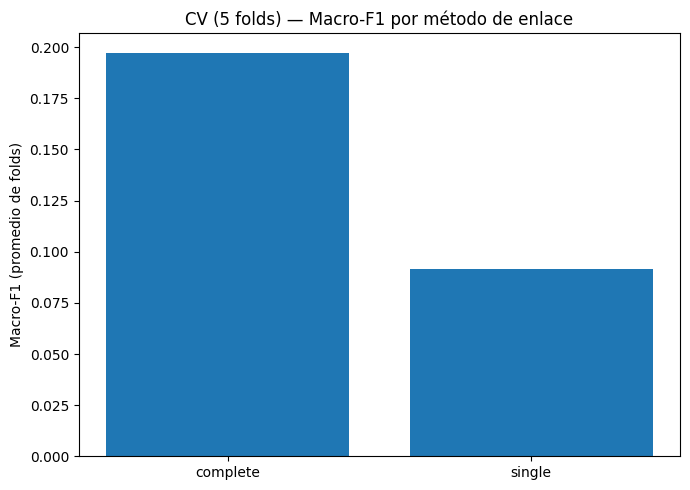

Figura guardada: /content/t6drive/MyDrive/taller6/figuras/cv_macroF1_por_metodo.png


In [43]:
# --- CELDA SS-3 ---
# Dentro del 5% etiquetado, corre CV (k-fold CV (k=5)) para elegir el MÉTODO de enlace (single vs complete).
# Para cada fold:
#  - Pool = fold_train_labeled + 85% no etiquetado
#  - Pre-clustering K-medoids (g=80) en el pool
#  - Jerárquico sobre medoides (single y complete)
#  - Elegir K por Silhouette (en el pool) para cada método
#  - Mapear clúster→clase por mayoría (usando SOLO fold_train_labeled)
#  - Predecir fold_valid_labeled y medir macro-F1/accuracy/recall
# Promediar por método y elegir el mejor (macro-F1).

g_fixed = 80
rng = np.random.default_rng(42)
K_range = range(2, 13)
methods = ["single", "complete"]

# Índices relativos sobre el pool combinado en cada fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_per_method = {m: [] for m in methods}

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_lab, y_train_lab), start=1):
    # Conjuntos etiquetados del 5% (fold)
    X_lab_tr, y_lab_tr = X_train_lab[tr_idx], y_train_lab[tr_idx]
    X_lab_va, y_lab_va = X_train_lab[va_idx], y_train_lab[va_idx]

    # Pool para SSL: fold_train_labeled + 85% unlabeled
    X_pool = np.vstack([X_train_unl, X_lab_tr])
    y_pool_labeled = np.concatenate([np.array(['__unl__']*len(X_train_unl)), y_lab_tr])
    pool_labeled_idx = np.arange(len(X_train_unl), len(X_pool))  # posiciones de las etiquetadas dentro del pool

    # Distancias en el pool y PAM (g=80)
    D_pool = euclidean_distances(X_pool)
    labels_protos, medoid_indices, _ = pam_kmedoids(D_pool, g_fixed, max_iter=20, rng=rng)
    M = X_pool[medoid_indices]  # medoides reales

    # Jerárquico por método y K por Silhouette
    for meth in methods:
        Z, Dm = build_linkage_on_medoids(M, method=meth)
        K_best, sil_best = choose_K_by_silhouette(D_pool, labels_protos, Z, K_range=K_range)

        # Etiquetas finales en TODO el pool con el K elegido
        labels_medoids = fcluster(Z, t=K_best, criterion="maxclust") - 1
        labels_full_pool = labels_medoids[labels_protos]

        # Mapeo clúster→clase (solo con fold_train_labeled dentro del pool)
        mapping = majority_map_cluster_to_class(labels_full_pool, y_pool_labeled, pool_labeled_idx)
        # fallback: clase más frecuente en fold_train_labeled (por si algún clúster no tiene votos)
        fallback_class = pd.Series(y_lab_tr).value_counts().idxmax()
        # Predecir fold_valid (sacamos sus etiquetas desde el árbol)
        # Para ello, necesitamos etiquetar X_lab_va a clúster: las filas de validación NO están en el pool.
        # Asignamos cada X_lab_va al protocluster más cercano (en el espacio de X):
        # 1) Medoides M, 2) distancias de X_lab_va a M, 3) etiqueta de clúster del medoid ganador.
        from sklearn.metrics import pairwise_distances
        D_val_to_M = pairwise_distances(X_lab_va, M, metric="euclidean")
        medoid_winner = np.argmin(D_val_to_M, axis=1)
        y_cluster_val = labels_medoids[medoid_winner]
        # Convertimos clúster → clase
        y_pred_val = apply_mapping_predict(y_cluster_val, mapping, fallback_class=fallback_class)

        # Métricas en fold_valid
        mets = compute_metrics(y_lab_va, y_pred_val, labels=np.unique(y_train_lab))
        results_per_method[meth].append(mets)

# Promedios por método
summary_rows = []
for meth in methods:
    macro_f1 = np.mean([r["macro_f1"] for r in results_per_method[meth]])
    acc = np.mean([r["accuracy"] for r in results_per_method[meth]])
    rec = np.mean([r["macro_recall"] for r in results_per_method[meth]])
    summary_rows.append({"method": meth, "macro_f1": macro_f1, "accuracy": acc, "macro_recall": rec})

cv_summary_df = pd.DataFrame(summary_rows).sort_values("macro_f1", ascending=False)
display(cv_summary_df)

# Elegir mejor método por macro-F1
best_method = cv_summary_df.iloc[0]["method"]
print(f"Mejor método por CV (macro-F1): {best_method}")

plt.figure(figsize=(7,5))
plt.bar(cv_summary_df["method"], cv_summary_df["macro_f1"])
plt.ylabel("Macro-F1")
out = os.path.join(figs, "cv_macroF1_por_metodo.png")
plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
print(f"Figura guardada: {out}")


In [1]:
# --- CELDA SS-4 ---
# Con el método elegido en CV:
# - Pool final = 85% no etiquetado + 5% etiquetado completo
# - PAM (g=80) + jerárquico sobre medoides (método best_method)
# - Elegir K por Silhouette (pool completo)
# - Mapear clúster→clase por mayoría (usando SOLO el 5% etiquetado)
# - Predecir el 10% etiquetado y reportar macro-F1, accuracy, recall y matriz de confusión
# - Guardar dendrograma y curva Silhouette vs K en figs/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# Pool final
X_pool = np.vstack([X_train_unl, X_train_lab])
y_pool_labeled = np.concatenate([np.array(['__unl__']*len(X_train_unl)), y_train_lab])
pool_labeled_idx = np.arange(len(X_train_unl), len(X_pool))

# Distancias y PAM (g=80)
D_pool = euclidean_distances(X_pool)
labels_protos, medoid_indices, _ = pam_kmedoids(D_pool, g_fixed, max_iter=20, rng=np.random.default_rng(42))
M = X_pool[medoid_indices]

# Jerárquico con el mejor método
Z, Dm = build_linkage_on_medoids(M, method=best_method)

# Curva Silhouette vs K (pool completo) y elección de K
K_range = range(2, 13)
sil_values = []
best_K, best_sil = None, -1.0
for K in K_range:
    labels_medoids = fcluster(Z, t=K, criterion="maxclust") - 1
    labels_full = labels_medoids[labels_protos]
    sil = silhouette_score(D_pool, labels_full, metric="precomputed")
    sil_values.append(sil)
    if sil > best_sil:
        best_sil, best_K = sil, int(K)

print(f"Mejor K por Silhouette en el pool final: K={best_K}, Silhouette={best_sil:.4f}")

# Figura Silhouette vs K
import os
assert os.path.isdir(figs), "La carpeta 'figs' debe existir."
plt.figure(figsize=(8,5))
plt.plot(list(K_range), sil_values, marker="o")
plt.title(f"Silhouette vs K — método {best_method} (pool 5%+85%)")
plt.xlabel("K (número de clústeres)"); plt.ylabel("Silhouette")
out = os.path.join(figs, f"silhouette_vs_K_pool_{best_method}.png")
plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
print(f"Figura guardada: {out}")

# Dendrograma del modelo final
plt.figure(figsize=(12,6))
dendrogram(Z, no_labels=True, count_sort=True)
plt.title(f"Dendrograma final — enlace {best_method} (sobre medoides)")
plt.xlabel("Medoides"); plt.ylabel("Distancia")
out = os.path.join(figs, f"dendrograma_final_medoides_{best_method}.png")
plt.tight_layout(); plt.savefig(out, dpi=150); plt.show()
print(f"Figura guardada: {out}")

# Etiquetas finales en el pool con K* y mapeo a clases
labels_medoids = fcluster(Z, t=best_K, criterion="maxclust") - 1
labels_full_pool = labels_medoids[labels_protos]
cluster_to_class = majority_map_cluster_to_class(labels_full_pool, y_pool_labeled, pool_labeled_idx)

# Fallback si algún clúster carece de votos etiquetados
fallback_class = pd.Series(y_train_lab).value_counts().idxmax()
# Clasificación del 10% de validación:
from sklearn.metrics import pairwise_distances
D_val_to_M = pairwise_distances(X_val10, M, metric="euclidean")
medoid_winner = np.argmin(D_val_to_M, axis=1)
y_cluster_val = labels_medoids[medoid_winner]
y_pred_val = apply_mapping_predict(y_cluster_val, cluster_to_class, fallback_class=fallback_class)

# Métricas finales en el 10%
metrics_val = compute_metrics(y_val10, y_pred_val, labels=np.unique(y_all))
print({k:v for k,v in metrics_val.items() if k!='confusion'})

# Matriz de confusión (figura)
import itertools
cm = metrics_val["confusion"]
classes = np.unique(y_all)

plt.figure(figsize=(10,8))
plt.imshow(cm, interpolation='nearest')
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.xticks(range(len(classes)), classes, rotation=90)
plt.yticks(range(len(classes)), classes)
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    val = int(cm[i, j])
    if val > 0:
        plt.text(j, i, str(val), ha="center", va="center")
plt.tight_layout()
out = os.path.join(figs, "matriz_confusion_validacion10.png")
plt.savefig(out, dpi=150); plt.show()
print(f"Figura guardada: {out}")

# Tabla de correspondencia clúster ↔ clase (por mayoría) para documentar
cluster_labels = sorted(cluster_to_class.keys())
table_map = pd.DataFrame({
    "cluster_id": cluster_labels,
    "mapped_class": [cluster_to_class[c] if cluster_to_class[c] is not None else fallback_class for c in cluster_labels]
})
display(table_map)


NameError: name 'X_train_unl' is not defined